<a href="https://colab.research.google.com/github/josemesa0112/machine-learning-repository/blob/main/Machine_Learning_applied_to_Crime_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INSTALACIÓN Y CARGA DEL DATASET**

In [1]:
!pip install ucimlrepo -q

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
communities = fetch_ucirepo(id=183)

X = communities.data.features
y = communities.data.targets

print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Variable objetivo:", y.columns.tolist())

Dimensión de X: (1994, 127)
Dimensión de y: (1994, 1)
Variable objetivo: ['ViolentCrimesPerPop']


## **UNIFICAR DATOS**

In [4]:
df = pd.concat([X, y], axis=1)

print("Dimensión completa del dataset:", df.shape)
df.head()

Dimensión completa del dataset: (1994, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


## **REVISIÓN DE ESTRUCTURA GENERAL**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(100), int64(2), object(26)
memory usage: 1.9+ MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
state,1994.0,28.683551,16.397553,1.0,12.00,34.00,42.00,56.0
fold,1994.0,5.493982,2.873694,1.0,3.00,5.00,8.00,10.0
population,1994.0,0.057593,0.126906,0.0,0.01,0.02,0.05,1.0
householdsize,1994.0,0.463395,0.163717,0.0,0.35,0.44,0.54,1.0
racepctblack,1994.0,0.179629,0.253442,0.0,0.02,0.06,0.23,1.0
...,...,...,...,...,...,...,...,...
LandArea,1994.0,0.065231,0.109459,0.0,0.02,0.04,0.07,1.0
PopDens,1994.0,0.232854,0.203092,0.0,0.10,0.17,0.28,1.0
PctUsePubTrans,1994.0,0.161685,0.229055,0.0,0.02,0.07,0.19,1.0
LemasPctOfficDrugUn,1994.0,0.094052,0.240328,0.0,0.00,0.00,0.00,1.0


## **DEFINIR VARIABLE OBJETIVO**

In [7]:
target_col = "ViolentCrimesPerPop"

print("Variable objetivo:", target_col)
print(df[target_col].describe())

Variable objetivo: ViolentCrimesPerPop
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


## **ELIMINAR COLUMNAS IDENTIFICADORAS**

Estas columnas no aportan información relevante para la predicción ya que solo son identificadores.

In [8]:
cols_to_drop = []

for col in ["state", "county", "community", "communityname", "fold"]:
    if col in df.columns:
        cols_to_drop.append(col)

print("Columnas eliminadas:", cols_to_drop)

df_model = df.drop(columns=cols_to_drop)

print("Dimensión después de eliminar identificadores:", df_model.shape)

Columnas eliminadas: ['state', 'county', 'community', 'communityname', 'fold']
Dimensión después de eliminar identificadores: (1994, 123)


In [9]:
#print(df_model.dtypes[df_model.dtypes != "float64"])
print(" ")
print(df_model.isna().sum()[df_model.isna().sum() == 0])

 
population             0
householdsize          0
racepctblack           0
racePctWhite           0
racePctAsian           0
                      ..
LemasPctPolicOnPatr    0
LemasGangUnitDeploy    0
LemasPctOfficDrugUn    0
PolicBudgPerPop        0
ViolentCrimesPerPop    0
Length: 123, dtype: int64


## **CONVERTIR VARIABLES A NUMÉRICAS**

In [10]:
df_model= df_model.apply(pd.to_numeric, errors="coerce")

print(df_model.dtypes.value_counts())

float64    123
Name: count, dtype: int64


## **REVISAR DATOS FALTANTES**

In [11]:
missing_values = df_model.isnull().sum()
missing_percent = (missing_values / len(df_model)) * 100

missing_table = pd.DataFrame({
    "missing_values": missing_values,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)

missing_table[missing_table["missing_values"] > 0].head(30)

,missing_values,missing_percent
PolicAveOTWorked,1675,84.002006
LemasTotalReq,1675,84.002006
LemasSwFTFieldPerPop,1675,84.002006
PctPolicWhite,1675,84.002006
RacialMatchCommPol,1675,84.002006
LemasSwFTPerPop,1675,84.002006
LemasSwFTFieldOps,1675,84.002006
PolicReqPerOffic,1675,84.002006
LemasTotReqPerPop,1675,84.002006
LemasSwornFT,1675,84.002006


## **IMPUTACIÓN DE DATOS FALTANTES**

In [12]:
svmImputer = SVR(kernel='rbf')

svmImputer = IterativeImputer(estimator = svmImputer, max_iter=10, random_state=42)

df_model_imputed = pd.DataFrame(svmImputer.fit_transform(df_model), columns=df_model.columns)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [13]:
df_model_imputed.isna().sum()[df_model_imputed.isna().sum() != 0] #verificando los datos faltantes luego de la imputación

,0


## **ELIMINAR COLUMNAS CON MUCHOS DATOS FALTANTES**

Columnas con más del 40% de valores faltantes.

In [14]:
threshold_missing = 40

cols_high_missing = missing_table[
    missing_table["missing_percent"] > threshold_missing
].index.tolist()

# Nunca eliminar la variable objetivo
if target_col in cols_high_missing:
    cols_high_missing.remove(target_col)

print("Columnas con más del 40% de datos faltantes:")
print(cols_high_missing)

df_model = df_model.drop(columns=cols_high_missing)

print("Dimensión después de eliminar columnas con muchos faltantes:", df_model.shape)

Columnas con más del 40% de datos faltantes:
['PolicAveOTWorked', 'LemasTotalReq', 'LemasSwFTFieldPerPop', 'PctPolicWhite', 'RacialMatchCommPol', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'PolicReqPerOffic', 'LemasTotReqPerPop', 'LemasSwornFT', 'PolicPerPop', 'PolicBudgPerPop', 'LemasGangUnitDeploy', 'LemasPctPolicOnPatr', 'PolicCars', 'PolicOperBudg', 'PctPolicMinor', 'PctPolicAsian', 'PctPolicHisp', 'OfficAssgnDrugUnits', 'NumKindsDrugsSeiz', 'PctPolicBlack']
Dimensión después de eliminar columnas con muchos faltantes: (1994, 101)


Para la variable 'OtherPerCap' como solo tiene un dato faltante, le imputamos la media

In [15]:
df_model['OtherPerCap'][df_model['OtherPerCap'].isna() != 0] = df_model['OtherPerCap'].mean()

/tmp/ipykernel_52397/720923645.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_model['OtherPerCap'][df_model['OtherPerCap'].isna() != 0] = df_model['OtherPerCap'].mean()


In [16]:
df_model.isna().sum()[df_model.isna().sum() != 0] #verificando valores faltantes luego

,0


**VARIABLES CON BAJA VARIABILIDAD**

Una variable casi constante aporta poca información.

In [17]:
X_temp = df_model.drop(columns=[target_col])

low_variance_cols = []

for col in X_temp.columns:
    if X_temp[col].nunique(dropna=True) <= 1:
        low_variance_cols.append(col)

print("Columnas con baja variabilidad:", low_variance_cols)

df_model = df_model.drop(columns=low_variance_cols)

print("Dimensión después de eliminar baja variabilidad:", df_model.shape)

Columnas con baja variabilidad: []
Dimensión después de eliminar baja variabilidad: (1994, 101)


Para el dataset con imputación de datos

In [18]:
X_temp = df_model_imputed.drop(columns=[target_col])

low_variance_cols = []

for col in X_temp.columns:
    if X_temp[col].nunique(dropna=True) <= 1:
        low_variance_cols.append(col)

print("Columnas con baja variabilidad:", low_variance_cols)

df_model_imputed = df_model_imputed.drop(columns=low_variance_cols)

print("Dimensión después de eliminar baja variabilidad:", df_model_imputed.shape)

Columnas con baja variabilidad: []
Dimensión después de eliminar baja variabilidad: (1994, 123)


**VARIABLES MUY CORRELACIONADAS ENTRE SÍ**

Se eliminan variables correlacionadas entre si para reducir la redundancia

In [19]:
X_corr = df_model.drop(columns=[target_col]).corr().abs()

upper = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Cantidad de variables altamente correlacionadas entre sí:", len(high_corr_features))
high_corr_features

Cantidad de variables altamente correlacionadas entre sí: 32


['agePct16t24',
 'numbUrban',
 'pctWSocSec',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'NumUnderPov',
 'PctNotHSGrad',
 'PctOccupMgmtProf',
 'FemalePctDiv',
 'TotalPctDiv',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'NumIlleg',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctNotSpeakEnglWell',
 'PctLargHouseOccup',
 'PersPerOccupHous',
 'PersPerOwnOccHous',
 'PctHousOwnOcc',
 'OwnOccMedVal',
 'OwnOccHiQuart',
 'RentMedian',
 'RentHighQ',
 'MedRent',
 'PctForeignBorn']

Luego con el dataset con imputación de datos

In [20]:
X_corr = df_model_imputed.drop(columns=[target_col]).corr().abs()

upper = X_corr.where(
    np.triu(np.ones(X_corr.shape), k=1).astype(bool)
)

high_corr_features_imputed = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Cantidad de variables altamente correlacionadas entre sí:", len(high_corr_features_imputed))
high_corr_features_imputed

Cantidad de variables altamente correlacionadas entre sí: 38


['agePct16t24',
 'numbUrban',
 'pctWSocSec',
 'medFamInc',
 'perCapInc',
 'whitePerCap',
 'NumUnderPov',
 'PctNotHSGrad',
 'PctOccupMgmtProf',
 'FemalePctDiv',
 'TotalPctDiv',
 'PctKids2Par',
 'PctYoungKids2Par',
 'PctTeen2Par',
 'NumIlleg',
 'PctImmigRec5',
 'PctImmigRec8',
 'PctImmigRec10',
 'PctRecImmig5',
 'PctRecImmig8',
 'PctRecImmig10',
 'PctNotSpeakEnglWell',
 'PctLargHouseOccup',
 'PersPerOccupHous',
 'PersPerOwnOccHous',
 'PctHousOwnOcc',
 'OwnOccMedVal',
 'OwnOccHiQuart',
 'RentMedian',
 'RentHighQ',
 'MedRent',
 'PctForeignBorn',
 'LemasSwFTFieldOps',
 'LemasSwFTFieldPerPop',
 'PolicPerPop',
 'OfficAssgnDrugUnits',
 'PolicOperBudg',
 'PolicBudgPerPop']

**VERSIÓN REDUCIDA DEL DATASET**

Eliminamos variables redundantes con correlación mayor a 0.90.

In [21]:
df_reduced = df_model.drop(columns=high_corr_features)

print("Dimensión original después de limpieza básica:", df_model.shape)
print("Dimensión después de eliminar variables redundantes:", df_reduced.shape)

Dimensión original después de limpieza básica: (1994, 101)
Dimensión después de eliminar variables redundantes: (1994, 69)


Con el dataset de datos imputados

In [22]:
df_reduced_imputed = df_model_imputed.drop(columns=high_corr_features_imputed)

print("Dimensión original después de limpieza básica:", df_model_imputed.shape)
print("Dimensión después de eliminar variables redundantes:", df_reduced_imputed.shape)

Dimensión original después de limpieza básica: (1994, 123)
Dimensión después de eliminar variables redundantes: (1994, 85)


**SEPARAR VARIABLES PREDICTORAS Y OBJETIVO**

In [23]:
X_final = df_reduced.drop(columns=[target_col])
X_final_imputed = df_reduced_imputed.drop(columns=[target_col]) #para el dataset de datos imputados
y_final = df_reduced[target_col]

print("X_final:", X_final.shape)
print("X_final_imputed:", X_final_imputed.shape)
print("y_final:", y_final.shape)

X_final: (1994, 68)
X_final_imputed: (1994, 84)
y_final: (1994,)


**15) DIVISIÓN ENTRENAMIENTO-TEST**

80% para entrenamiento-validación y 20% para test final.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.20,
    random_state=42
)

X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split( # para los datos imputados
    X_final_imputed,
    y_final,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train_imputed:", X_train_imputed.shape)
print("Test_imputed:", X_test_imputed.shape)

Train: (1595, 68)
Test: (399, 68)
Train_imputed: (1595, 84)
Test_imputed: (399, 84)


# **ENTRENAMIENTO Y EVALUACIÓN DE MODELOS**

## Estandarización de la Configuración Experimental y Creación de Infraestructura Reutilizable

En esta etapa, nos enfocaremos en estandarizar la configuración experimental y crear una infraestructura reutilizable para la evaluación de todos los modelos. Esto asegura que cada modelo sea evaluado bajo las mismas condiciones para una comparación justa y rigurosa.

### Configuración Experimental Congelada:

*   **Datasets:** `df_reduced` y `df_reduced_imputed` (los dataset mas limpios y reducidos).
*   **División de Datos:** `train_test_split` (80% entrenamiento / 20% prueba, con `random_state=42`).
*   **Métricas:** MAE, RMSE y R².
*   **Validación Cruzada:** `KFold` de 8 folds, con `shuffle=True` y `random_state=42`.

### Función General de Evaluación:

Crearemos una función (`evaluate_regression_model`) que automatice la validación cruzada, el entrenamiento final y la evaluación en el conjunto de prueba para cualquier pipeline o modelo de regresión. Esto permitirá una fácil comparación de diferentes algoritmos.

#### Función `evaluate_regression_model`

Esta función encapsulará la lógica de evaluación, incluyendo:

*   Validación cruzada con las métricas y folds definidos.
*   Entrenamiento final del modelo con el conjunto completo de entrenamiento.
*   Evaluación en el conjunto de prueba.
*   Presentación organizada de los resultados.

In [25]:
def evaluate_regression_model(
    model_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    cv_strategy,
    scoring_metrics,
    model_name="Modelo"
):
    """
    Evalúa un pipeline o modelo de regresión usando validación cruzada y un conjunto de prueba.

    Args:
        model_pipeline (Pipeline o estimador): El pipeline o modelo de regresión a evaluar.
        X_train (pd.DataFrame): Características del conjunto de entrenamiento.
        y_train (pd.Series): Variable objetivo del conjunto de entrenamiento.
        X_test (pd.DataFrame): Características del conjunto de prueba.
        y_test (pd.Series): Variable objetivo del conjunto de prueba.
        cv_strategy (KFold): Estrategia de validación cruzada (ej. KFold).
        scoring_metrics (dict): Diccionario de métricas de scoring (ej. {"MAE": "neg_mean_absolute_error"}).
        model_name (str): Nombre del modelo para mostrar en los resultados.

    Returns:
        tuple: Contiene (test_mae, test_rmse, test_r2, y_pred).
    """

    print(f"\n--- Evaluación del Modelo: {model_name} ---")

    # --- 1. Validación Cruzada ---
    print("\nRealizando validación cruzada...")
    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring_metrics,
        return_train_score=True
    )

    # Reutilizar la función summarize_cv (definida previamente)
    def summarize_cv(cv_results, metric_name):
        train_values = cv_results[f"train_{metric_name}"]
        test_values = cv_results[f"test_{metric_name}"]

        if metric_name in ["MAE", "RMSE"]:
            train_values = -train_values
            test_values = -test_values

        mean = np.mean(test_values)
        std = np.std(test_values, ddof=1)

        return {
            "Train_mean": np.mean(train_values),
            "Validation_mean": mean,
            "Validation_std": std
        }

    summary_df = pd.DataFrame([
        {"Metric": "MAE", **summarize_cv(cv_results, "MAE")},
        {"Metric": "RMSE", **summarize_cv(cv_results, "RMSE")},
        {"Metric": "R2", **summarize_cv(cv_results, "R2")}
    ])
    print("\nResultados de Validación Cruzada:")
    display(summary_df)

    # --- 2. Entrenamiento Final y Evaluación en Test ---
    print("\nEntrenando el modelo final y evaluando en el conjunto de prueba...")
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_r2 = r2_score(y_test, y_pred)

    test_results_df = pd.DataFrame({
        "Metric": ["MAE", "RMSE", "R2"],
        "Test": [test_mae, test_rmse, test_r2]
    })
    print("\nResultados en el Conjunto de Prueba:")
    display(test_results_df)

    return (
        summary_df.loc[summary_df['Metric'] == 'MAE', 'Validation_mean'].iloc[0],
        summary_df.loc[summary_df['Metric'] == 'RMSE', 'Validation_mean'].iloc[0],
        summary_df.loc[summary_df['Metric'] == 'R2', 'Validation_mean'].iloc[0],
        test_mae,
        test_rmse,
        test_r2,
        y_pred
    )


#### Tabla Maestra de Resultados Comparativos

Esta tabla se utilizará para almacenar los resultados clave de cada modelo evaluado, facilitando la comparación entre ellos.

In [26]:
# Crear la tabla maestra vacía
master_results_df = pd.DataFrame(
    columns=[
        "Modelo",
        "Val_MAE",
        "Val_RMSE",
        "Val_R2",
        "Test_MAE",
        "Test_RMSE",
        "Test_R2"
    ]
)

print("Tabla maestra de resultados creada:")
display(master_results_df)


Tabla maestra de resultados creada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2


## **REGRESIÓN LINEAL**

### Evaluación del Modelo de Regresión Lineal con la Nueva Función

Ahora, utilizaremos la función `evaluate_regression_model` para evaluar el pipeline de Regresión Lineal que ya hemos definido y añadiremos sus resultados a la tabla maestra.

In [27]:
linear_regression_pipeline = Pipeline(steps=[
    ("model", LinearRegression())
])

cv = KFold(n_splits=8, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}


--- Evaluación del Modelo: Regresión Lineal ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.092907,0.098442,0.005320
1,RMSE,0.131422,0.138712,0.008441
2,R2,0.689433,0.646758,0.058989



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.094536
1,RMSE,0.132840
2,R2,0.631562



Tabla maestra de resultados actualizada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.13284,0.631562


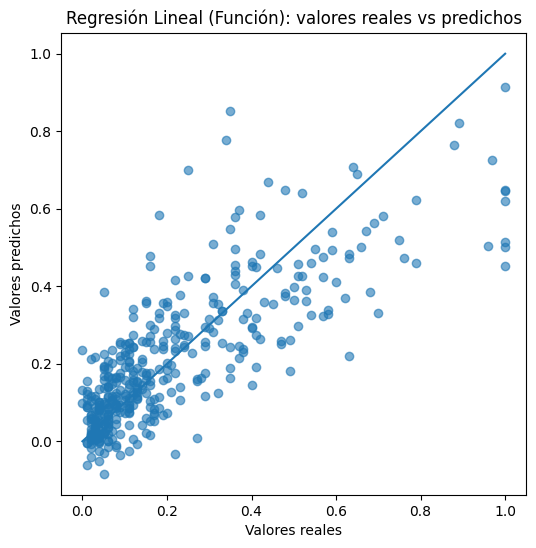

In [28]:
val_mae_lr, val_rmse_lr, val_r2_lr, test_mae_lr, test_rmse_lr, test_r2_lr, y_pred_lr = \
    evaluate_regression_model(
        linear_regression_pipeline,
        X_train, y_train, X_test, y_test,
        cv,
        scoring,
        model_name="Regresión Lineal"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Regresión Lineal"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Regresión Lineal",
    val_mae_lr,
    val_rmse_lr,
    val_r2_lr,
    test_mae_lr,
    test_rmse_lr,
    test_r2_lr
]

print("\nTabla maestra de resultados actualizada:")
# Se muestra la tabla maestra con los resultados de Regresión Lineal
display(master_results_df)

# Opcional: Visualizar de nuevo los reales vs predichos para Regresión Lineal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal (Función): valores reales vs predichos")
plt.show()

### Regresión Lineal con datos imputados


--- Evaluación del Modelo: Regresión Lineal Imputada ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.089227,0.096665,0.006379
1,RMSE,0.125689,0.136752,0.009081
2,R2,0.715964,0.658226,0.046909



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.088409
1,RMSE,0.126226
2,R2,0.667338



Tabla maestra de resultados actualizada:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.132840,0.631562
1,Regresión Lineal Imputada,0.096665,0.136752,0.658226,0.088409,0.126226,0.667338


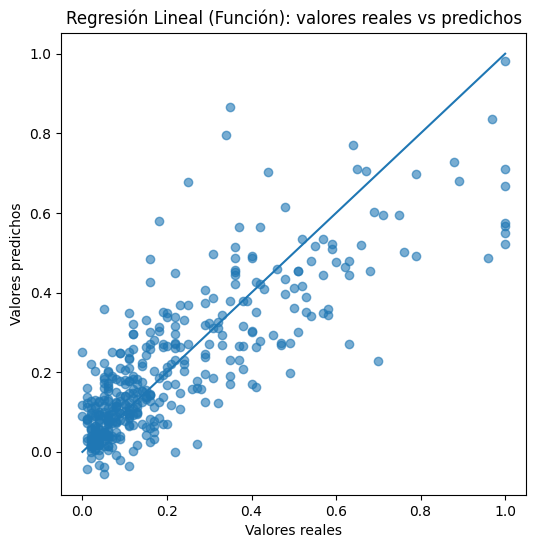

In [29]:
val_mae_lr, val_rmse_lr, val_r2_lr, test_mae_lr, test_rmse_lr, test_r2_lr, y_pred_lr = \
    evaluate_regression_model(
        linear_regression_pipeline,
        X_train_imputed, y_train_imputed, X_test_imputed, y_test_imputed,
        cv,
        scoring,
        model_name="Regresión Lineal Imputada"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Regresión Lineal Imputada"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Regresión Lineal Imputada",
    val_mae_lr,
    val_rmse_lr,
    val_r2_lr,
    test_mae_lr,
    test_rmse_lr,
    test_r2_lr
]

print("\nTabla maestra de resultados actualizada:")
# Se muestra la tabla maestra con los resultados de Regresión Lineal
display(master_results_df)

# Opcional: Visualizar de nuevo los reales vs predichos para Regresión Lineal
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión Lineal (Función): valores reales vs predichos")
plt.show()

## RANDOM FOREST

Ahora implementaremos el modelo Random Forest Regressor, siguiendo la misma configuración experimental definida anteriormente para una comparación justa y rigurosa.

### Random Forest Regressor con `RandomizedSearchCV`

Primero usaremos`RandomizedSearchCV` para buscar una combinación óptima de hiperparámetros que controlen la complejidad del modelo.

### Estrategia de Busqueda:

1.  **Modelo base**: `RandomForestRegressor`.
2.  **Estrategia de búsqueda**: `RandomizedSearchCV` para explorar eficientemente un gran espacio de hiperparámetros.
3.  **Validación cruzada**: Se mantendrá la misma estrategia `KFold` (`n_splits=8`, `shuffle=True`, `random_state=42`) para la evaluación de los hiperparámetros.
4.  **Métrica de optimización**: Se usará `scoring='r2'` para maximizar la varianza explicada.
5.  **Hiperparámetros a optimizar**: Se probarán rangos adecuados para `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, y `max_features` para fomentar modelos menos complejos.
6.  **Configuración de `RandomizedSearchCV`**: `n_iter` entre 30 y 50, `random_state=42`, `n_jobs=-1` para paralelización.

In [30]:
# Importar RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Definir el pipeline con el imputer y scaler
# El modelo Random Forest se especificará en la búsqueda de hiperparámetros
rf_pipeline_base = Pipeline(steps=[
    ("model", RandomForestRegressor(random_state=42))
])

# Definir los rangos de hiperparámetros para RandomizedSearchCV
# Se eligen rangos para controlar el sobreajuste
param_distributions = {
    'model__n_estimators': np.linspace(50, 200, 16, dtype=int),  # Número de árboles
    'model__max_depth': np.append(np.linspace(5, 20, 10, dtype=int), [None]), # Profundidad máxima del árbol, incluyendo sin límite
    'model__min_samples_split': np.linspace(2, 10, 9, dtype=int)  , # Mínimo de muestras para dividir un nodo
    'model__min_samples_leaf': np.linspace(1, 10, 10, dtype=int)  , # Mínimo de muestras en una hoja
    'model__max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0] # Número de features a considerar en cada split
}

# Inicializar RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline_base,
    param_distributions=param_distributions,
    n_iter=40,  # Número de combinaciones de hiperparámetros a probar
    cv=cv,      # La estrategia de validación cruzada definida previamente
    scoring='r2', # Métrica a optimizar
    random_state=42,
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=1,
    return_train_score=True # Asegurar que se guarden los scores de entrenamiento
)

print("Iniciando la búsqueda de hiperparámetros para Random Forest...")
random_search_rf.fit(X_train, y_train)

print("Búsqueda completada.")

Iniciando la búsqueda de hiperparámetros para Random Forest...
Fitting 8 folds for each of 40 candidates, totalling 320 fits
Búsqueda completada.


Resultados de la Busqueda

In [31]:
# Mejor score de R2 en validación cruzada
best_r2_cv = random_search_rf.best_score_
print(f"Mejor R2 en CV: {best_r2_cv:.4f}")

# Mejores hiperparámetros encontrados
best_params = random_search_rf.best_params_
print("Mejores hiperparámetros:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Mejor modelo estimado
optimized_rf_pipeline = random_search_rf.best_estimator_

# Obtener el R2 de entrenamiento para el mejor estimador de los resultados de RandomizedSearchCV
# Se toma el R2 de entrenamiento promedio del mejor estimador de la validación cruzada
best_index = random_search_rf.best_index_
rf_r2_opt_train_cv = random_search_rf.cv_results_['mean_train_score'][best_index]

# Evaluar el modelo optimizado en el conjunto de prueba usando la función `evaluate_regression_model`
val_mae_rf_opt, val_rmse_rf_opt, val_r2_rf_opt, test_mae_rf_opt, test_rmse_rf_opt, test_r2_rf_opt, y_pred_rf_opt = \
    evaluate_regression_model(
        optimized_rf_pipeline,
        X_train, y_train, X_test, y_test,
        cv,
        scoring,
        model_name="Random Forest"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Random Forest"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Random Forest",
    val_mae_rf_opt,
    val_rmse_rf_opt,
    val_r2_rf_opt,
    test_mae_rf_opt,
    test_rmse_rf_opt,
    test_r2_rf_opt
]

print("\nTabla maestra de resultados actualizada con Random Forest Optimizado:")
display(master_results_df)

Mejor R2 en CV: 0.6614
Mejores hiperparámetros:
  model__n_estimators: 160
  model__min_samples_split: 10
  model__min_samples_leaf: 3
  model__max_features: 0.6
  model__max_depth: 16

--- Evaluación del Modelo: Random Forest ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.050666,0.094271,0.005228
1,RMSE,0.076948,0.135874,0.008414
2,R2,0.893518,0.661363,0.054443



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.092133
1,RMSE,0.134207
2,R2,0.623941



Tabla maestra de resultados actualizada con Random Forest Optimizado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.132840,0.631562
1,Regresión Lineal Imputada,0.096665,0.136752,0.658226,0.088409,0.126226,0.667338
2,Random Forest,0.094271,0.135874,0.661363,0.092133,0.134207,0.623941


### Random Forest Regressor con imputación de datos

ahora realizaremos el mismo proceso de entrenamiento para buscar el mejor modelo con el dataset con datos imputados

In [32]:
# Importar RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

# El modelo Random Forest se especificará en la búsqueda de hiperparámetros
rf_pipeline_base = Pipeline(steps=[
    ("model", RandomForestRegressor(random_state=42))
])

# Definir los rangos de hiperparámetros para RandomizedSearchCV
# Se eligen rangos para controlar el sobreajuste
param_distributions = {
    'model__n_estimators': np.linspace(50, 200, 16, dtype=int),  # Número de árboles
    'model__max_depth': np.append(np.linspace(5, 20, 10, dtype=int), [None]), # Profundidad máxima del árbol, incluyendo sin límite
    'model__min_samples_split': np.linspace(2, 10, 9, dtype=int)  , # Mínimo de muestras para dividir un nodo
    'model__min_samples_leaf': np.linspace(1, 10, 10, dtype=int)  , # Mínimo de muestras en una hoja
    'model__max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0] # Número de features a considerar en cada split
}

# Inicializar RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_pipeline_base,
    param_distributions=param_distributions,
    n_iter=40,  # Número de combinaciones de hiperparámetros a probar
    cv=cv,      # La estrategia de validación cruzada definida previamente
    scoring='r2', # Métrica a optimizar
    random_state=42,
    n_jobs=-1,  # Usar todos los cores disponibles
    verbose=1,
    return_train_score=True # Asegurar que se guarden los scores de entrenamiento
)

print("Iniciando la búsqueda de hiperparámetros para Random Forest...")
random_search_rf.fit(X_train_imputed, y_train_imputed)

print("Búsqueda completada.")

Iniciando la búsqueda de hiperparámetros para Random Forest...
Fitting 8 folds for each of 40 candidates, totalling 320 fits
Búsqueda completada.


evaluando resultados de la busqueda

In [33]:
# Mejor score de R2 en validación cruzada
best_r2_cv = random_search_rf.best_score_
print(f"Mejor R2 en CV: {best_r2_cv:.4f}")

# Mejores hiperparámetros encontrados
best_params = random_search_rf.best_params_
print("Mejores hiperparámetros:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Mejor modelo estimado
optimized_rf_pipeline = random_search_rf.best_estimator_

# Obtener el R2 de entrenamiento para el mejor estimador de los resultados de RandomizedSearchCV
# Se toma el R2 de entrenamiento promedio del mejor estimador de la validación cruzada
best_index = random_search_rf.best_index_
rf_r2_opt_train_cv = random_search_rf.cv_results_['mean_train_score'][best_index]

# Evaluar el modelo optimizado en el conjunto de prueba usando la función `evaluate_regression_model`
val_mae_rf_opt, val_rmse_rf_opt, val_r2_rf_opt, test_mae_rf_opt, test_rmse_rf_opt, test_r2_rf_opt, y_pred_rf_opt = \
    evaluate_regression_model(
        optimized_rf_pipeline,
        X_train_imputed, y_train_imputed, X_test_imputed, y_test_imputed,
        cv,
        scoring,
        model_name="Random Forest Imputed"
    )

# Eliminar la entrada existente si el modelo ya está en la tabla
master_results_df = master_results_df[master_results_df['Modelo'] != "Random Forest Imputed"].reset_index(drop=True)
# Añadir los resultados a la tabla maestra
master_results_df.loc[len(master_results_df)] = [
    "Random Forest Imputed",
    val_mae_rf_opt,
    val_rmse_rf_opt,
    val_r2_rf_opt,
    test_mae_rf_opt,
    test_rmse_rf_opt,
    test_r2_rf_opt
]

print("\nTabla maestra de resultados actualizada con Random Forest Optimizado:")
display(master_results_df)

Mejor R2 en CV: 0.6789
Mejores hiperparámetros:
  model__n_estimators: 160
  model__min_samples_split: 10
  model__min_samples_leaf: 3
  model__max_features: 0.6
  model__max_depth: 16

--- Evaluación del Modelo: Random Forest Imputed ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.048471,0.092446,0.005760
1,RMSE,0.073263,0.132585,0.008331
2,R2,0.903500,0.678900,0.041480



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.087955
1,RMSE,0.128013
2,R2,0.657854



Tabla maestra de resultados actualizada con Random Forest Optimizado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
0,Regresión Lineal,0.098442,0.138712,0.646758,0.094536,0.132840,0.631562
1,Regresión Lineal Imputada,0.096665,0.136752,0.658226,0.088409,0.126226,0.667338
2,Random Forest,0.094271,0.135874,0.661363,0.092133,0.134207,0.623941
3,Random Forest Imputed,0.092446,0.132585,0.678900,0.087955,0.128013,0.657854


## SUPPORT VECTOR MACHINE (SVM)

Ahora implementaremos el modelo Support Vector Regression (SVR), siguiendo la misma configuración experimental definida anteriormente para una comparación justa y rigurosa.

### Optimización de Support Vector Regression (SVR) con Diferentes Hiperparámetros

Ahora evaluaremos el SVR con las diferentes configuraciones de `kernel`, `C` y `degree` (para kernels polinomiales) o `gamma` (para kernels RBF) especificadas.


--- Evaluando SVR con configuración: SVR (Kernel: Linear, C=1) ---

--- Evaluación del Modelo: SVR (Kernel: Linear, C=1) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.093077,0.098308,0.005238
1,RMSE,0.132799,0.139617,0.008570
2,R2,0.682888,0.642719,0.055793



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.093989
1,RMSE,0.133545
2,R2,0.627645



--- Evaluando SVR con configuración: SVR (Kernel: Linear, C=0.01) ---

--- Evaluación del Modelo: SVR (Kernel: Linear, C=0.01) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


...


Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.095201
1,RMSE,0.135356
2,R2,0.617475



Tabla maestra de resultados actualizada con SVR tuneado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
1,"SVR (Kernel: Linear, C=1)",0.098308,0.139617,0.642719,0.093989,0.133545,0.627645
2,"SVR (Kernel: Linear, C=0.01)",0.097663,0.140827,0.637902,0.091202,0.131582,0.638511
3,"SVR (Kernel: Linear, C=100)",0.098675,0.139958,0.640954,0.094741,0.133933,0.625479
4,"SVR (Kernel: Poly, C=1, Deg=3)",0.115855,0.160452,0.527207,0.112326,0.156102,0.491229
5,"SVR (Kernel: Poly, C=0.01, Deg=3)",0.095637,0.136619,0.658788,0.090202,0.129842,0.648005
6,"SVR (Kernel: Poly, C=100, Deg=3)",0.133173,0.183292,0.382863,0.127596,0.173270,0.373169
7,"SVR (Kernel: Poly, C=1, Deg=5)",0.128772,0.181426,0.394959,0.122816,0.170894,0.390243
8,"SVR (Kernel: Poly, C=0.01, Deg=5)",0.101713,0.142022,0.630381,0.101217,0.144233,0.565656
9,"SVR (Kernel: Poly, C=100, Deg=5)",0.128772,0.181426,0.394959,0.122816,0.170894,0.390243
10,"SVR (Kernel: Poly, C=1, Deg=7)",0.130393,0.188238,0.346881,0.123291,0.176992,0.345949


/tmp/ipykernel_52397/96814242.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Test_R2', data=svr_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')


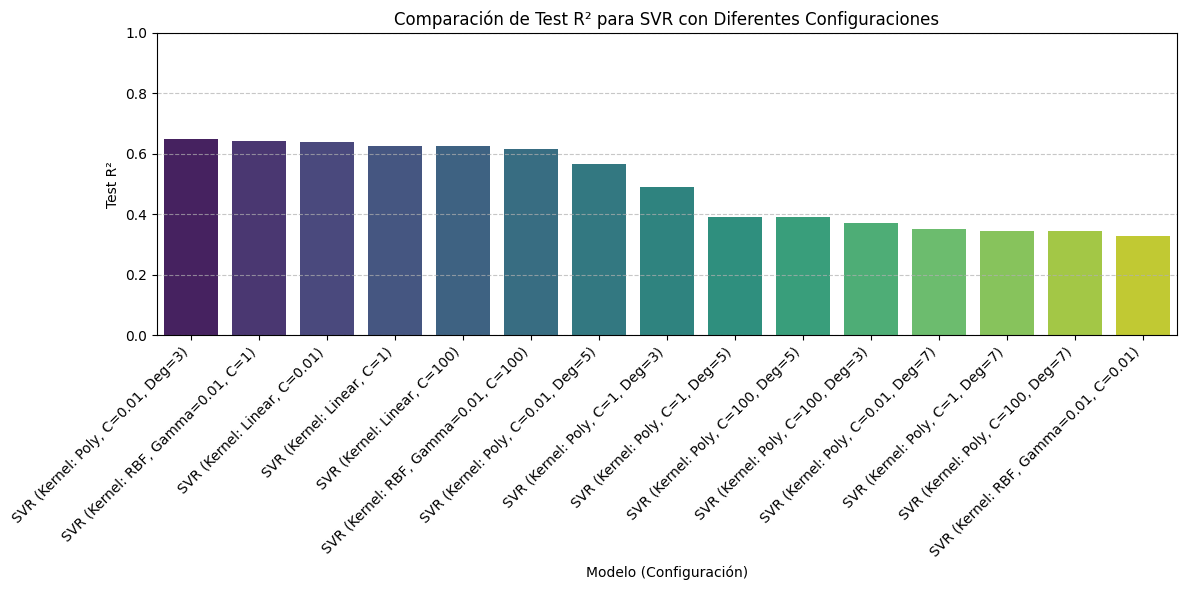

In [33]:
from sklearn.svm import SVR

# Definir las configuraciones de hiperparámetros para SVR
svr_configs = [
    {"kernel": "linear", "C": 1.0, "model_name": "SVR (Kernel: Linear, C=1)"},
    {"kernel": "linear", "C": 1e-2, "model_name": "SVR (Kernel: Linear, C=0.01)"},
    {"kernel": "linear", "C": 1e2, "model_name": "SVR (Kernel: Linear, C=100)"},
    {"kernel": "poly", "C": 1.0, "degree": 3, "model_name": "SVR (Kernel: Poly, C=1, Deg=3)"},
    {"kernel": "poly", "C": 1e-2, "degree": 3, "model_name": "SVR (Kernel: Poly, C=0.01, Deg=3)"},
    {"kernel": "poly", "C": 1e2, "degree": 3, "model_name": "SVR (Kernel: Poly, C=100, Deg=3)"},
    {"kernel": "poly", "C": 1.0, "degree": 5, "model_name": "SVR (Kernel: Poly, C=1, Deg=5)"},
    {"kernel": "poly", "C": 1e-2, "degree": 5, "model_name": "SVR (Kernel: Poly, C=0.01, Deg=5)"},
    {"kernel": "poly", "C": 1e2, "degree": 5, "model_name": "SVR (Kernel: Poly, C=100, Deg=5)"},
    {"kernel": "poly", "C": 1.0, "degree": 7, "model_name": "SVR (Kernel: Poly, C=1, Deg=7)"},
    {"kernel": "poly", "C": 1e-2, "degree": 7, "model_name": "SVR (Kernel: Poly, C=0.01, Deg=7)"},
    {"kernel": "poly", "C": 1e2, "degree": 7, "model_name": "SVR (Kernel: Poly, C=100, Deg=7)"},
    {"kernel": "rbf", "C": 1.0, "gamma": 1e-2, "model_name": "SVR (Kernel: RBF, Gamma=0.01, C=1)"},
    {"kernel": "rbf", "C": 1e-2, "gamma": 1e-2, "model_name": "SVR (Kernel: RBF, Gamma=0.01, C=0.01)"},
    {"kernel": "rbf", "C": 1e2, "gamma": 1e-2, "model_name": "SVR (Kernel: RBF, Gamma=0.01, C=100)"}
]

svr_tuning_results = []

for config in svr_configs:
    print(f"\n--- Evaluando SVR con configuración: {config['model_name']} ---")

    # Extraer parámetros de la configuración
    params = {k: v for k, v in config.items() if k != 'model_name'}

    # Construir el pipeline para SVR con la configuración actual
    svr_pipeline_tuned = Pipeline(steps=[
        ("model", SVR(**params))
    ])

    model_name_svr_tuned = config['model_name']

    val_mae_svr_tuned, val_rmse_svr_tuned, val_r2_svr_tuned, test_mae_svr_tuned, test_rmse_svr_tuned, test_r2_svr_tuned, y_pred_svr_tuned = \
        evaluate_regression_model(
            svr_pipeline_tuned,
            X_train, y_train, X_test, y_test,
            cv,
            scoring,
            model_name=model_name_svr_tuned
        )

    # Eliminar la entrada existente si el modelo ya está en la tabla
    master_results_df = master_results_df[master_results_df['Modelo'] != model_name_svr_tuned].reset_index(drop=True)
    # Añadir los resultados a la tabla maestra
    master_results_df.loc[len(master_results_df)] = [
        model_name_svr_tuned,
        val_mae_svr_tuned,
        val_rmse_svr_tuned,
        val_r2_svr_tuned,
        test_mae_svr_tuned,
        test_rmse_svr_tuned,
        test_r2_svr_tuned
    ]
    svr_tuning_results.append({
        'Modelo': model_name_svr_tuned,
        'Test_R2': test_r2_svr_tuned
    })

print("\nTabla maestra de resultados actualizada con SVR tuneado:")
display(master_results_df[master_results_df['Modelo'].str.contains('SVR')])

# Generar gráfica de comparación de Test R² para diferentes configuraciones de SVR
svr_plot_df = pd.DataFrame(svr_tuning_results)
plt.figure(figsize=(12, 6))
sns.barplot(x='Modelo', y='Test_R2', data=svr_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')
plt.title('Comparación de Test R² para SVR con Diferentes Configuraciones')
plt.xlabel('Modelo (Configuración)')
plt.ylabel('Test R²')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ahora entrenamos el modelo con el dataset de datos imputados


--- Evaluando SVR con configuración: SVR Imputed (Kernel: Linear, C=1) ---

--- Evaluación del Modelo: SVR Imputed (Kernel: Linear, C=1) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.090383,0.096925,0.006712
1,RMSE,0.127687,0.137463,0.009675
2,R2,0.706854,0.654490,0.050646



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.089667
1,RMSE,0.129109
2,R2,0.651969



--- Evaluando SVR con configuración: SVR Imputed (Kernel: Linear, C=0.01) ---

--- Evaluación del Modelo: SVR Imputed (Kernel: Linear, C=0.01) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


...


Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.087070
1,RMSE,0.124791
2,R2,0.674858



Tabla maestra de resultados actualizada con SVR tuneado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
16,"SVR Imputed (Kernel: Linear, C=1)",0.096925,0.137463,0.654490,0.089667,0.129109,0.651969
17,"SVR Imputed (Kernel: Linear, C=0.01)",0.096337,0.138743,0.648774,0.089101,0.128444,0.655548
18,"SVR Imputed (Kernel: Linear, C=100)",0.097990,0.139032,0.646678,0.088935,0.127297,0.661669
19,"SVR Imputed (Kernel: Poly, C=1, Deg=3)",0.102578,0.144548,0.618869,0.091867,0.128989,0.652617
20,"SVR Imputed (Kernel: Poly, C=0.01, Deg=3)",0.094303,0.134409,0.670706,0.087626,0.124734,0.675157
21,"SVR Imputed (Kernel: Poly, C=100, Deg=3)",0.104585,0.147929,0.600733,0.093248,0.130060,0.646826
22,"SVR Imputed (Kernel: Poly, C=1, Deg=5)",0.105551,0.150186,0.587884,0.093534,0.131375,0.639645
23,"SVR Imputed (Kernel: Poly, C=0.01, Deg=5)",0.097735,0.136054,0.662005,0.091456,0.130064,0.646805
24,"SVR Imputed (Kernel: Poly, C=100, Deg=5)",0.105551,0.150186,0.587884,0.093534,0.131375,0.639645
25,"SVR Imputed (Kernel: Poly, C=1, Deg=7)",0.107965,0.156702,0.549436,0.096428,0.137986,0.602468


/tmp/ipykernel_52397/4017507791.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Test_R2', data=svr_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')


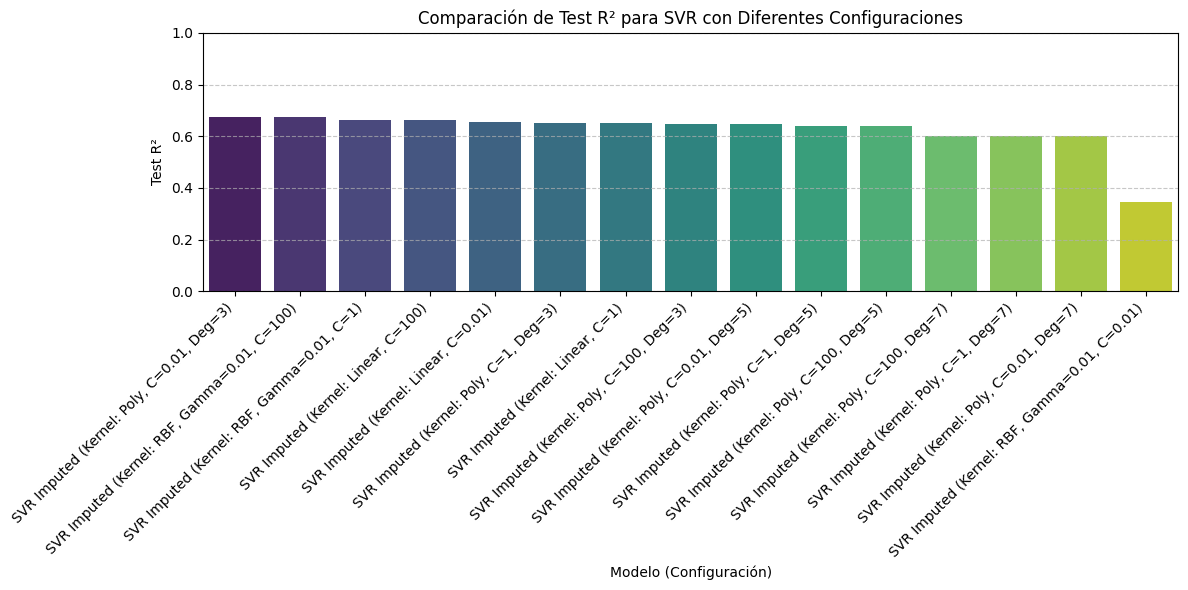

In [34]:
from sklearn.svm import SVR

# Definir las configuraciones de hiperparámetros para SVR
svr_configs = [
    {"kernel": "linear", "C": 1.0, "model_name": "SVR Imputed (Kernel: Linear, C=1)"},
    {"kernel": "linear", "C": 1e-2, "model_name": "SVR Imputed (Kernel: Linear, C=0.01)"},
    {"kernel": "linear", "C": 1e2, "model_name": "SVR Imputed (Kernel: Linear, C=100)"},
    {"kernel": "poly", "C": 1.0, "degree": 3, "model_name": "SVR Imputed (Kernel: Poly, C=1, Deg=3)"},
    {"kernel": "poly", "C": 1e-2, "degree": 3, "model_name": "SVR Imputed (Kernel: Poly, C=0.01, Deg=3)"},
    {"kernel": "poly", "C": 1e2, "degree": 3, "model_name": "SVR Imputed (Kernel: Poly, C=100, Deg=3)"},
    {"kernel": "poly", "C": 1.0, "degree": 5, "model_name": "SVR Imputed (Kernel: Poly, C=1, Deg=5)"},
    {"kernel": "poly", "C": 1e-2, "degree": 5, "model_name": "SVR Imputed (Kernel: Poly, C=0.01, Deg=5)"},
    {"kernel": "poly", "C": 1e2, "degree": 5, "model_name": "SVR Imputed (Kernel: Poly, C=100, Deg=5)"},
    {"kernel": "poly", "C": 1.0, "degree": 7, "model_name": "SVR Imputed (Kernel: Poly, C=1, Deg=7)"},
    {"kernel": "poly", "C": 1e-2, "degree": 7, "model_name": "SVR Imputed (Kernel: Poly, C=0.01, Deg=7)"},
    {"kernel": "poly", "C": 1e2, "degree": 7, "model_name": "SVR Imputed (Kernel: Poly, C=100, Deg=7)"},
    {"kernel": "rbf", "C": 1.0, "gamma": 1e-2, "model_name": "SVR Imputed (Kernel: RBF, Gamma=0.01, C=1)"},
    {"kernel": "rbf", "C": 1e-2, "gamma": 1e-2, "model_name": "SVR Imputed (Kernel: RBF, Gamma=0.01, C=0.01)"},
    {"kernel": "rbf", "C": 1e2, "gamma": 1e-2, "model_name": "SVR Imputed (Kernel: RBF, Gamma=0.01, C=100)"}
]

svr_tuning_results = []

for config in svr_configs:
    print(f"\n--- Evaluando SVR con configuración: {config['model_name']} ---")

    # Extraer parámetros de la configuración
    params = {k: v for k, v in config.items() if k != 'model_name'}

    # Construir el pipeline para SVR con la configuración actual
    svr_pipeline_tuned = Pipeline(steps=[
        ("model", SVR(**params))
    ])

    model_name_svr_tuned = config['model_name']

    val_mae_svr_tuned, val_rmse_svr_tuned, val_r2_svr_tuned, test_mae_svr_tuned, test_rmse_svr_tuned, test_r2_svr_tuned, y_pred_svr_tuned = \
        evaluate_regression_model(
            svr_pipeline_tuned,
            X_train_imputed, y_train_imputed, X_test_imputed, y_test_imputed,
            cv,
            scoring,
            model_name=model_name_svr_tuned
        )

    # Eliminar la entrada existente si el modelo ya está en la tabla
    master_results_df = master_results_df[master_results_df['Modelo'] != model_name_svr_tuned].reset_index(drop=True)
    # Añadir los resultados a la tabla maestra
    master_results_df.loc[len(master_results_df)] = [
        model_name_svr_tuned,
        val_mae_svr_tuned,
        val_rmse_svr_tuned,
        val_r2_svr_tuned,
        test_mae_svr_tuned,
        test_rmse_svr_tuned,
        test_r2_svr_tuned
    ]
    svr_tuning_results.append({
        'Modelo': model_name_svr_tuned,
        'Test_R2': test_r2_svr_tuned
    })

print("\nTabla maestra de resultados actualizada con SVR tuneado:")
display(master_results_df[master_results_df['Modelo'].str.contains('SVR Imputed')])

# Generar gráfica de comparación de Test R² para diferentes configuraciones de SVR
svr_plot_df = pd.DataFrame(svr_tuning_results)
plt.figure(figsize=(12, 6))
sns.barplot(x='Modelo', y='Test_R2', data=svr_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')
plt.title('Comparación de Test R² para SVR con Diferentes Configuraciones')
plt.xlabel('Modelo (Configuración)')
plt.ylabel('Test R²')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## K-NEAREST NEIGHBORS (KNN)

Ahora implementaremos el modelo K-Nearest Neighbors (KNN) Regressor, siguiendo la misma configuración experimental definida anteriormente para una comparación justa y rigurosa. KNN es un algoritmo no paramétrico que realiza predicciones basándose en la similitud con las observaciones más cercanas en el espacio de características.

### K-Neighbors Regressor con Diferentes valores de `n_neighbors`

Vamos a evaluar el modelo K-Neighbors Regressor con un conjunto de valores para el hiperparámetro n_neighbors para encontrar la configuración óptima.


--- Evaluando K-Neighbors Regressor con n_neighbors = 5 ---

--- Evaluación del Modelo: K-Neighbors Regressor (n=5) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.084147,0.102924,0.005725
1,RMSE,0.122086,0.149335,0.009494
2,R2,0.732003,0.593510,0.045343



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.095805
1,RMSE,0.137310
2,R2,0.606353



--- Evaluando K-Neighbors Regressor con n_neighbors = 8 ---

--- Evaluación del Modelo: K-Neighbors Regressor (n=8) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


...


Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.097149
1,RMSE,0.137423
2,R2,0.605702



Tabla maestra de resultados actualizada con K-Neighbors Regressor tuneado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2
31,K-Neighbors Regressor (n=5),0.102924,0.149335,0.593510,0.095805,0.137310,0.606353
32,K-Neighbors Regressor (n=8),0.101313,0.147934,0.600763,0.093471,0.134417,0.622767
33,K-Neighbors Regressor (n=10),0.101341,0.148227,0.598948,0.094654,0.136477,0.611113
34,K-Neighbors Regressor (n=12),0.101170,0.147565,0.602713,0.093571,0.135196,0.618379
35,K-Neighbors Regressor (n=15),0.100327,0.146839,0.606441,0.091210,0.132100,0.635660
36,K-Neighbors Regressor (n=17),0.100558,0.147181,0.604764,0.092405,0.133186,0.629645
37,K-Neighbors Regressor (n=20),0.101112,0.147934,0.600760,0.092917,0.133224,0.629433
38,K-Neighbors Regressor (n=25),0.101225,0.148487,0.597868,0.093724,0.134292,0.623466
39,K-Neighbors Regressor (n=30),0.101255,0.148682,0.596907,0.094226,0.134733,0.620988
40,K-Neighbors Regressor (n=40),0.101835,0.149623,0.591763,0.094939,0.135168,0.618540


/tmp/ipykernel_52397/3461240020.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Test_R2', data=knn_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')


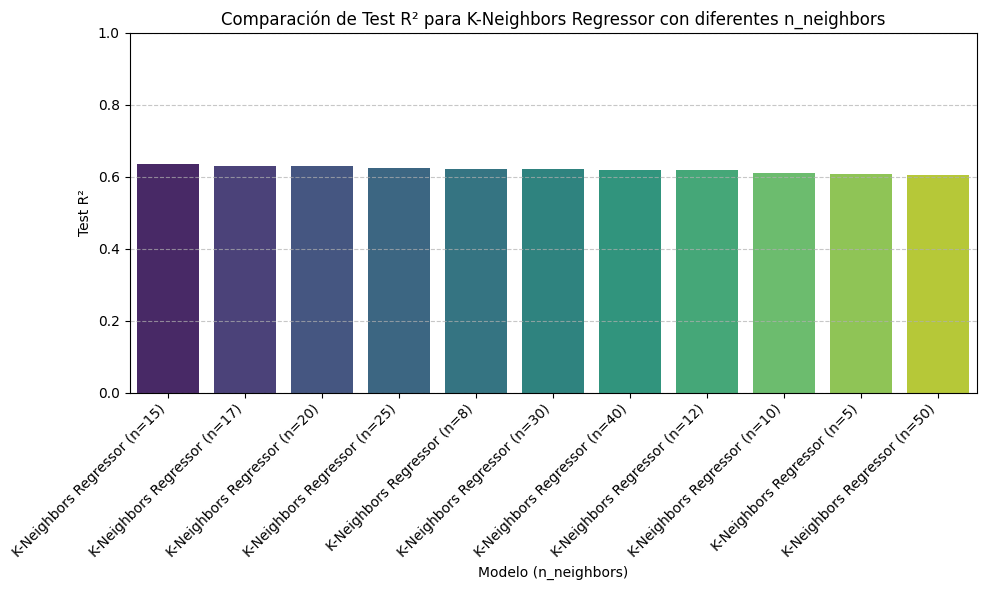

In [46]:
from sklearn.neighbors import KNeighborsRegressor

# Definir la lista de valores de n_neighbors a probar
n_neighbors_list = [5, 8, 10, 12, 15, 17, 20, 25, 30, 40, 50]

knn_tuning_results = []

for n_neigh in n_neighbors_list:
    print(f"\n--- Evaluando K-Neighbors Regressor con n_neighbors = {n_neigh} ---")

    # Construir el pipeline para KNN Regressor con el n_neighbors actual
    knn_pipeline_tuned = Pipeline(steps=[
        ("model", KNeighborsRegressor(n_neighbors=n_neigh))
    ])

    model_name_knn_tuned = f"K-Neighbors Regressor (n={n_neigh})"

    val_mae_knn_tuned, val_rmse_knn_tuned, val_r2_knn_tuned, test_mae_knn_tuned, test_rmse_knn_tuned, test_r2_knn_tuned, y_pred_knn_tuned = \
        evaluate_regression_model(
            knn_pipeline_tuned,
            X_train, y_train, X_test, y_test,
            cv,
            scoring,
            model_name=model_name_knn_tuned
        )

    # Eliminar la entrada existente si el modelo ya está en la tabla
    master_results_df = master_results_df[master_results_df['Modelo'] != model_name_knn_tuned].reset_index(drop=True)
    # Añadir los resultados a la tabla maestra
    master_results_df.loc[len(master_results_df)] = [
        model_name_knn_tuned,
        val_mae_knn_tuned,
        val_rmse_knn_tuned,
        val_r2_knn_tuned,
        test_mae_knn_tuned,
        test_rmse_knn_tuned,
        test_r2_knn_tuned
    ]
    knn_tuning_results.append({
        'Modelo': model_name_knn_tuned,
        'Test_R2': test_r2_knn_tuned
    })

print("\nTabla maestra de resultados actualizada con K-Neighbors Regressor tuneado:")
display(master_results_df[master_results_df['Modelo'].str.contains('K-Neighbors Regressor')])

# Generar gráfica de comparación de Test R² para diferentes n_neighbors
knn_plot_df = pd.DataFrame(knn_tuning_results)
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Test_R2', data=knn_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')
plt.title('Comparación de Test R² para K-Neighbors Regressor con diferentes n_neighbors')
plt.xlabel('Modelo (n_neighbors)')
plt.ylabel('Test R²')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### K-Neighbors Regressor con imputación de datos

Ahora vamos a evaluar el modelo variando con los mismos valores el hiperparametro n_neighbors pero con el dataset de datos imputados.


--- Evaluando K-Neighbors Regressor con n_neighbors = 5 ---

--- Evaluación del Modelo: K-Neighbors Regressor imputed (n=5) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


,Metric,Train_mean,Validation_mean,Validation_std
0,MAE,0.084147,0.102924,0.005725
1,RMSE,0.122086,0.149335,0.009494
2,R2,0.732003,0.593510,0.045343



Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.095805
1,RMSE,0.137310
2,R2,0.606353



--- Evaluando K-Neighbors Regressor con n_neighbors = 8 ---

--- Evaluación del Modelo: K-Neighbors Regressor imputed (n=8) ---

Realizando validación cruzada...

Resultados de Validación Cruzada:


...


Entrenando el modelo final y evaluando en el conjunto de prueba...

Resultados en el Conjunto de Prueba:


,Metric,Test
0,MAE,0.097149
1,RMSE,0.137423
2,R2,0.605702



Tabla maestra de resultados actualizada con K-Neighbors Regressor tuneado:


,Modelo,Val_MAE,Val_RMSE,Val_R2,Test_MAE,Test_RMSE,Test_R2


/tmp/ipykernel_52397/3342201835.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Test_R2', data=knn_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')


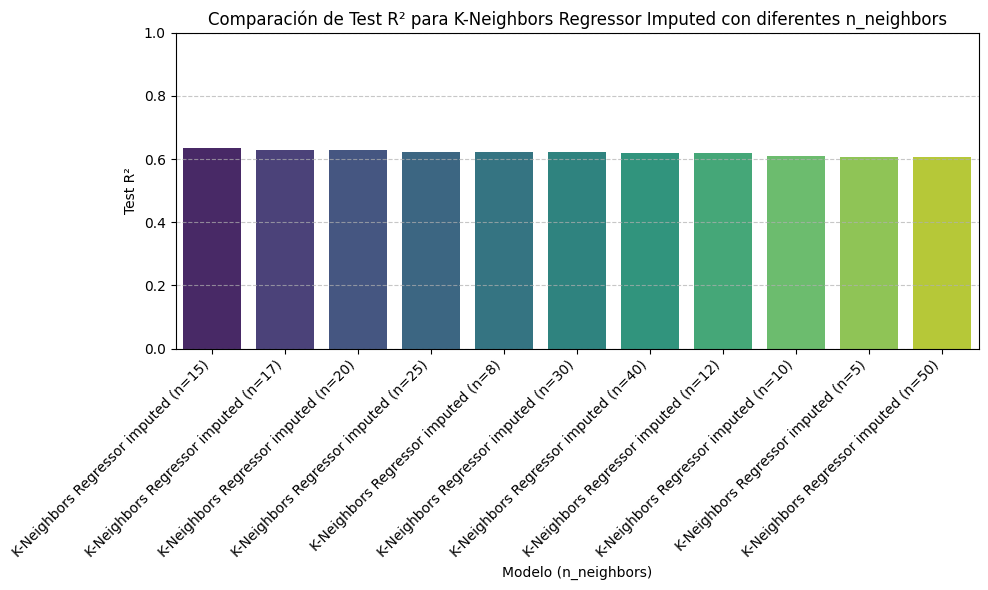

In [48]:
from sklearn.neighbors import KNeighborsRegressor

# Definir la lista de valores de n_neighbors a probar
n_neighbors_list = [5, 8, 10, 12, 15, 17, 20, 25, 30, 40, 50]

knn_tuning_results = []

for n_neigh in n_neighbors_list:
    print(f"\n--- Evaluando K-Neighbors Regressor con n_neighbors = {n_neigh} ---")

    # Construir el pipeline para KNN Regressor con el n_neighbors actual
    knn_pipeline_tuned = Pipeline(steps=[
        ("model", KNeighborsRegressor(n_neighbors=n_neigh))
    ])

    model_name_knn_tuned = f"K-Neighbors Regressor imputed (n={n_neigh})"

    val_mae_knn_tuned, val_rmse_knn_tuned, val_r2_knn_tuned, test_mae_knn_tuned, test_rmse_knn_tuned, test_r2_knn_tuned, y_pred_knn_tuned = \
        evaluate_regression_model(
            knn_pipeline_tuned,
            X_train, y_train, X_test, y_test,
            cv,
            scoring,
            model_name=model_name_knn_tuned
        )

    # Eliminar la entrada existente si el modelo ya está en la tabla
    master_results_df = master_results_df[master_results_df['Modelo'] != model_name_knn_tuned].reset_index(drop=True)
    # Añadir los resultados a la tabla maestra
    master_results_df.loc[len(master_results_df)] = [
        model_name_knn_tuned,
        val_mae_knn_tuned,
        val_rmse_knn_tuned,
        val_r2_knn_tuned,
        test_mae_knn_tuned,
        test_rmse_knn_tuned,
        test_r2_knn_tuned
    ]
    knn_tuning_results.append({
        'Modelo': model_name_knn_tuned,
        'Test_R2': test_r2_knn_tuned
    })

print("\nTabla maestra de resultados actualizada con K-Neighbors Regressor tuneado:")
display(master_results_df[master_results_df['Modelo'].str.contains('K-Neighbors Regressor Imputed')])

# Generar gráfica de comparación de Test R² para diferentes n_neighbors
knn_plot_df = pd.DataFrame(knn_tuning_results)
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Test_R2', data=knn_plot_df.sort_values(by='Test_R2', ascending=False), palette='viridis')
plt.title('Comparación de Test R² para K-Neighbors Regressor Imputed con diferentes n_neighbors')
plt.xlabel('Modelo (n_neighbors)')
plt.ylabel('Test R²')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()